In [1]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

written answers are in the PDF submission

In [2]:
# functions

def compute_metrics(y_train, y_train_pred, y_train_prob, y_test, y_test_pred, y_test_prob, pos_label):
    """
    computes the main metrics for training and testing and returns in a dataframe
    """
    metrics_df = pd.DataFrame({
        "Metric": ["Error", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
        "Training": [
            1 - accuracy_score(y_train, y_train_pred),
            accuracy_score(y_train, y_train_pred),
            precision_score(y_train, y_train_pred, pos_label=pos_label),
            recall_score(y_train, y_train_pred, pos_label=pos_label),
            f1_score(y_train, y_train_pred, pos_label=pos_label),
            roc_auc_score((y_train == pos_label).astype(int), y_train_prob)
        ],
        "Testing": [
            1 - accuracy_score(y_test, y_test_pred),
            accuracy_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred, pos_label=pos_label),
            recall_score(y_test, y_test_pred, pos_label=pos_label),
            f1_score(y_test, y_test_pred, pos_label=pos_label),
            roc_auc_score((y_test == pos_label).astype(int), y_test_prob)
        ]
    })
    return metrics_df.round(3)

def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test, pos_label):
    """
    fits a model, makes predictions, and evaluates by returning a table of metrics
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    metrics_df = compute_metrics(
        y_train, y_train_pred, y_train_prob,
        y_test, y_test_pred, y_test_prob,
        pos_label=pos_label
    )

    return model, metrics_df

def run_parameter_sweep(model_class, param_name, param_values, X_train, y_train, X_val, y_val, fixed_params=None):
    """
    trains a model using different values of one parameter and returns results
    """
    if fixed_params is None:
        fixed_params = {}

    results = []

    for value in param_values:
        params = fixed_params.copy()
        params[param_name] = value

        model = model_class(**params)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        results.append({
            param_name: value,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "validation_accuracy": accuracy_score(y_val, val_pred),
            "num_nodes": model.tree_.node_count
        })

    return pd.DataFrame(results).round(3)

def plot_metric_curve(results_df, x_col, y_cols, xlabel, ylabel, title):
    """
    # plots metric columns against a chosen x-axis column
    """
    plt.figure(figsize=(8, 5))

    for col in y_cols:
        plt.plot(results_df[x_col], results_df[col], marker="o", label=col)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_roc_curves(models, model_names, X_test, y_test, pos_label):
    """
    plots roc curves for multiple models
    """
    y_test_binary = (y_test == pos_label).astype(int)

    plt.figure(figsize=(8, 6))

    for model, name in zip(models, model_names):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
        auc_score = roc_auc_score(y_test_binary, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def run_ensemble_experiment(model_class, n_values, X_train, y_train, X_test, y_test, param_name, pos_label, fixed_params=None):
    """
    fits an ensemble model for several values of a size parameter
    """
    if fixed_params is None:
        fixed_params = {}

    all_results = []

    for value in n_values:
        params = fixed_params.copy()
        params[param_name] = value

        model = model_class(**params)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        metrics_df = compute_metrics(
            y_train, y_train_pred, y_train_prob,
            y_test, y_test_pred, y_test_prob,
            pos_label=pos_label
        )

        metrics_df = metrics_df.rename(columns={
            "Training": f"Training_{value}",
            "Testing": f"Testing_{value}"
        })

        all_results.append(metrics_df.set_index("Metric"))

    combined_df = pd.concat(all_results, axis=1).reset_index()
    return combined_df

def get_feature_importance_table(model, feature_names, top_n=None):
    """
    extracts feature importances from a fitted tree model
    """
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    return importance_df.reset_index(drop=True)

def plot_feature_importance(importance_df, title="Feature Importances"):
    """
    plots a bar chart of feature importances
    """
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Problem 1 [Decision Trees]

a. use an existing package to train a decision tree on the ADULT training data without pruning. use the information gain splitting criteria. compute the training and testing error, accuracy, precision, recall, F1 score, and AUC and report these metrics. write down some observations about the training and testing metrics.

In [3]:
# column names
adult_colnames = ["age", "workclass", "fnlwgt", "education", "education_num",
                  "marital_status", "occupation", "relationship", "race",
                  "sex", "capital_gain", "capital_loss", "hours_per_week",
                  "native_country", "income"]

# read in datasets
adult_train = pd.read_csv("adult/adult.data", header=None, names=adult_colnames)
adult_test = pd.read_csv("adult/adult.test", header=None, names=adult_colnames, skiprows=1)

# remove redundant columns (education)
adult_train = adult_train.drop(columns=["education"])
adult_test = adult_test.drop(columns=["education"])

# remove spaces at start
adult_train = adult_train.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
adult_test = adult_test.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# remove period at end of label (ex: ">50K.")
adult_train["income"] = adult_train["income"].str.replace(".", "", regex=False)
adult_test["income"] = adult_test["income"].str.replace(".", "", regex=False)

# remove NA values
adult_train = adult_train.dropna()
adult_test = adult_test.dropna()

In [4]:
# separate X and y
X_train = adult_train.drop(columns=["income"])
y_train = adult_train["income"]
X_test = adult_test.drop(columns=["income"])
y_test = adult_test["income"]

# encode categorical variables
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [5]:
# train decision tree (information gain)
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",  # information gain
    random_state=42)

# fit and evaluate model using function
dt_entropy, adult_metrics = fit_and_evaluate_model(
    model=dt_entropy,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    pos_label=">50K"
)

adult_metrics

,Metric,Training,Testing
0,Error,0.0,0.186
1,Accuracy,1.0,0.814
2,Precision,1.0,0.604
3,Recall,1.0,0.615
4,F1 Score,1.0,0.610
5,AUC,1.0,0.745


b. change the splitting criteria to use the gini index and report the same metrics. compare them to the information gain metrics and write your observations.

In [6]:
# train decision tree (gini index)
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# fit and evaluate
dt_gini, gini_metrics = fit_and_evaluate_model(
    model=dt_gini,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    pos_label=">50K"
)

gini_metrics

,Metric,Training,Testing
0,Error,0.0,0.189
1,Accuracy,1.0,0.811
2,Precision,1.0,0.597
3,Recall,1.0,0.616
4,F1 Score,1.0,0.607
5,AUC,1.0,0.744


c. split the training data into a 80% subset for training the decision tree and a 20% subset for validation. implement and test three early stopping or pruning criteria for decision trees:
1. setting up a maximum depth for the decision tree. select at least 6 different tree depth levels and plot a graph that shows the training and validation set accuracies as a function of the depth. report in a table the total number of nodes in the decision tree for the different depth levels. discuss your observations.
2. bounding the minimum number of nodes in a leaf. select at least 6 different values for this parameter and plot a graph that shows the training and validation set accuracies as a function of this parameter. report in a table the total number of nodes in the decision tree for the different values of this parameter. discuss your observations.
3. cost-complexity pruning. select at least 6 different values for parameter $\alpha$ and plot a graph that shows the training and validation set accuracies as a function of $\alpha$. report in a table the total number of nodes in the decision tree for the different values. discuss your observations.

In [7]:
# 80/20 split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

### setting up a maximum depth for the decision tree

In [8]:
# six different depth levels
depth_values = [1, 2, 3, 5, 10, 15, 20]

depth_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="max_depth",
    param_values=depth_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different depth levels
depth_results

,max_depth,train_accuracy,validation_accuracy,num_nodes
0,1,0.759,0.759,3
1,2,0.828,0.828,7
2,3,0.844,0.845,15
3,5,0.846,0.848,55
4,10,0.865,0.860,483
5,15,0.897,0.851,1803
6,20,0.929,0.841,3505


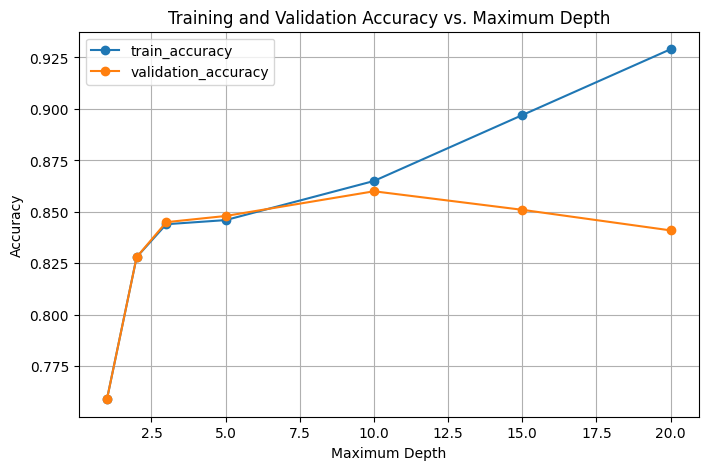

In [9]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=depth_results,
    x_col="max_depth",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Maximum Depth",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Maximum Depth"
)

### bounding the minimum number of nodes in a leaf

In [10]:
# values for minimum number of nodes in a leaf
leaf_values = [1, 2, 5, 10, 20, 50, 100]

leaf_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="min_samples_leaf",
    param_values=leaf_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different values
leaf_results

,min_samples_leaf,train_accuracy,validation_accuracy,num_nodes
0,1,1.000,0.823,7357
1,2,0.964,0.826,6387
2,5,0.920,0.833,3753
3,10,0.893,0.851,2231
4,20,0.878,0.856,1271
5,50,0.865,0.857,581
6,100,0.859,0.855,321


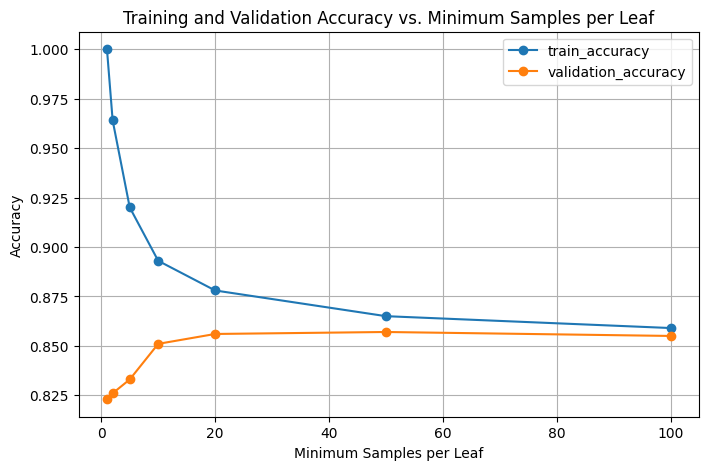

In [11]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=leaf_results,
    x_col="min_samples_leaf",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Minimum Samples per Leaf",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Minimum Samples per Leaf"
)

### cost-complexity pruning

In [12]:
# values for parameter alpha
alpha_values = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

alpha_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="ccp_alpha",
    param_values=alpha_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different values
alpha_results

,ccp_alpha,train_accuracy,validation_accuracy,num_nodes
0,0.000,1.000,0.823,7357
1,0.000,0.963,0.835,4695
2,0.000,0.859,0.859,115
3,0.001,0.854,0.855,55
4,0.005,0.843,0.845,21
5,0.010,0.843,0.845,13
6,0.050,0.759,0.759,3


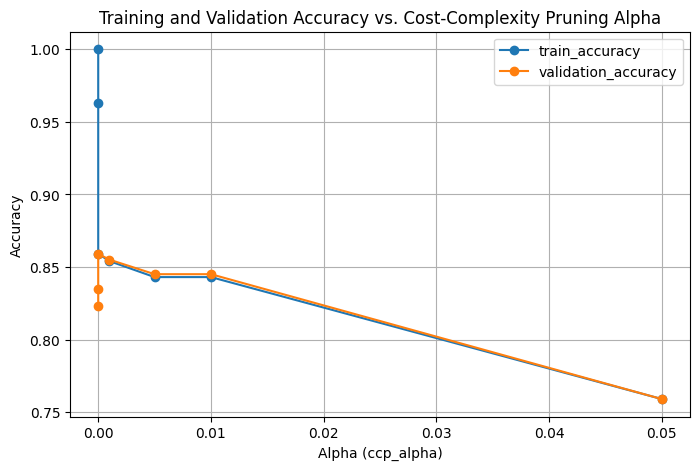

In [13]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=alpha_results,
    x_col="ccp_alpha",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Alpha (ccp_alpha)",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Cost-Complexity Pruning Alpha"
)

# Problem 2 [Random Forest Ensemble]

a. use an existing package to train a random forest ensemble with 10, 50, 100, and 500 decision trees on the ADULT dataset. report accuracy, precision, recall, F1 score, and AUC on both the training and testing sets for T values 10, 50, 100, 500. how do the metrics change as T increases?

In [14]:
# values for number of trees (T)
tree_values = [10, 50, 100, 500]

# run random forest
rf_results = run_ensemble_experiment(
    model_class=RandomForestClassifier,
    n_values=tree_values,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_name="n_estimators",
    fixed_params={
        "random_state": 42
    },
    pos_label=">50K"
)

rf_results

,Metric,Training_10,Testing_10,Training_50,Testing_50,Training_100,Testing_100,Training_500,Testing_500
0,Error,0.012,0.155,0.000,0.149,0.0,0.146,0.0,0.146
1,Accuracy,0.988,0.845,1.000,0.851,1.0,0.854,1.0,0.854
2,Precision,0.994,0.715,1.000,0.722,1.0,0.727,1.0,0.726
3,Recall,0.955,0.568,0.999,0.603,1.0,0.609,1.0,0.611
4,F1 Score,0.974,0.633,0.999,0.657,1.0,0.663,1.0,0.664
5,AUC,0.999,0.877,1.000,0.899,1.0,0.903,1.0,0.905


b. compare the metrics obtained for random forest with the decision tree metrics obtained in problem 1. write down some observations.

c. compute the variable importance for each feature and include a plot. discuss your observations on which features contribute most to the prediction.

In [15]:
# get feature importances from the random forest with 100 trees
rf_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_100.fit(X_train, y_train)

importance_df = get_feature_importance_table(
    model=rf_100,
    feature_names=X_train.columns,
    top_n=None
)

importance_df

,Feature,Importance
0,fnlwgt,0.168615
1,age,0.152929
2,education_num,0.108483
3,capital_gain,0.097654
4,hours_per_week,0.083298
...,...,...
87,native_country_Outlying-US(Guam-USVI-etc),0.000030
88,occupation_Armed-Forces,0.000014
89,native_country_Honduras,0.000008
90,workclass_Never-worked,0.000002


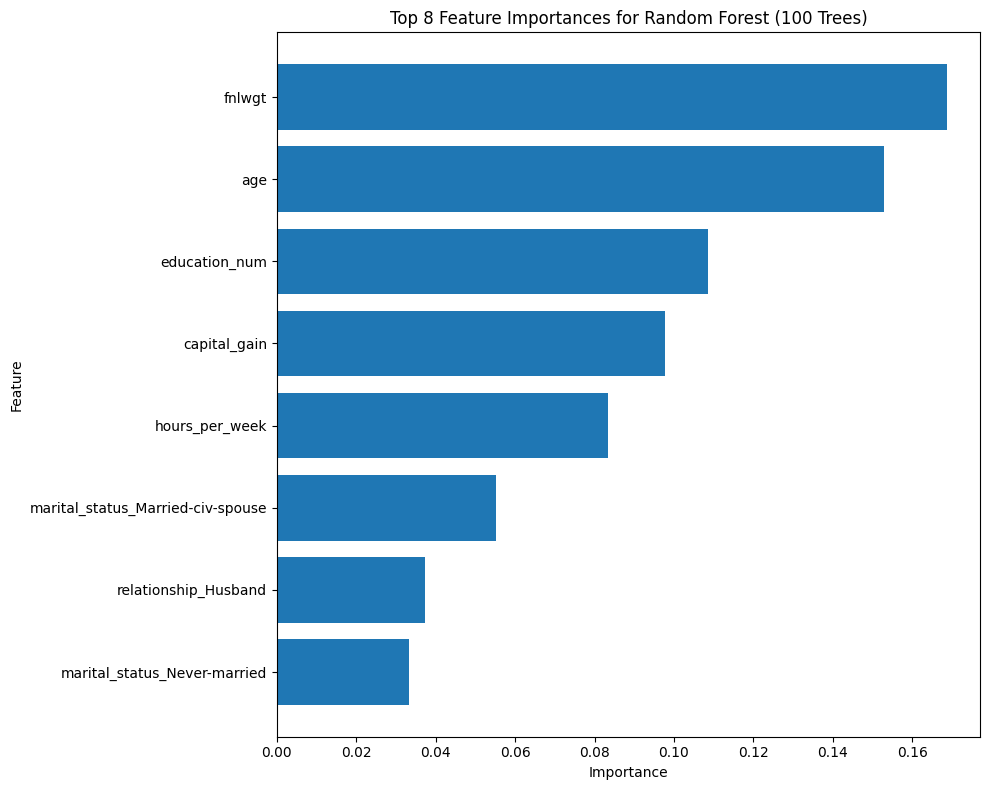

In [16]:
# plot top 8 most important features
top_importance_df = get_feature_importance_table(
    model=rf_100,
    feature_names=X_train.columns,
    top_n=8
)

plot_feature_importance(
    importance_df=top_importance_df,
    title="Top 8 Feature Importances for Random Forest (100 Trees)"
)

# Problem 3 [AdaBoost and GradientBoost Ensemble]

a. use an existing package to train and adaboost and gradientboost ensemble with 10, 50, 100, and 500 base classifiers on the ADULT dataset. use a decision tree classifier as the base classification model. report accuracy, precision, recall, F1 score, and AUC on both the training and testing sets. set max depth of each tree to 3 and learning rate to 0.1

In [17]:
# values for number of base classifiers
n_values = [10, 50, 100, 500]

In [18]:
# base decision tree for adaboost
base_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# run adaboost
adaboost_results = run_ensemble_experiment(
    model_class=AdaBoostClassifier,
    n_values=n_values,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_name="n_estimators",
    fixed_params={
        "estimator": base_tree,
        "learning_rate": 0.1,
        "random_state": 42
    },
    pos_label=">50K"
)

adaboost_results

,Metric,Training_10,Testing_10,Training_50,Testing_50,Training_100,Testing_100,Training_500,Testing_500
0,Error,0.151,0.150,0.146,0.146,0.145,0.144,0.142,0.138
1,Accuracy,0.849,0.850,0.854,0.854,0.855,0.856,0.858,0.862
2,Precision,0.759,0.758,0.794,0.790,0.793,0.786,0.774,0.776
3,Recall,0.544,0.536,0.529,0.523,0.539,0.535,0.581,0.583
4,F1 Score,0.634,0.628,0.635,0.629,0.642,0.637,0.663,0.666
5,AUC,0.870,0.870,0.906,0.905,0.910,0.908,0.916,0.914


In [19]:
# run gradientboost
gradientboost_results = run_ensemble_experiment(
    model_class=GradientBoostingClassifier,
    n_values=n_values,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_name="n_estimators",
    fixed_params={
        "learning_rate": 0.1,
        "max_depth": 3,
        "random_state": 42
    },
    pos_label=">50K"
)

gradientboost_results

,Metric,Training_10,Testing_10,Training_50,Testing_50,Training_100,Testing_100,Training_500,Testing_500
0,Error,0.155,0.153,0.139,0.137,0.131,0.129,0.113,0.122
1,Accuracy,0.845,0.847,0.861,0.863,0.869,0.871,0.887,0.878
2,Precision,0.820,0.822,0.798,0.797,0.798,0.795,0.818,0.787
3,Recall,0.456,0.452,0.565,0.564,0.612,0.611,0.683,0.660
4,F1 Score,0.586,0.583,0.662,0.661,0.692,0.691,0.744,0.718
5,AUC,0.890,0.891,0.918,0.915,0.926,0.921,0.944,0.928


b. compare adaboost, gradientboost, and randomforest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training and testing sets.

c. plot the ROC curves for the decision tree model, random forest with 100 trees, gradientboost and adaboost with 100 trees. discuss your observations.

In [20]:
# decision tree
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_entropy.fit(X_train, y_train)

# random forest with 100 trees
rf_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_100.fit(X_train, y_train)

# adaboost with 100 base learners
base_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
adaboost_100 = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_100.fit(X_train, y_train)

# gradientboost with 100 base learners
gradientboost_100 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gradientboost_100.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


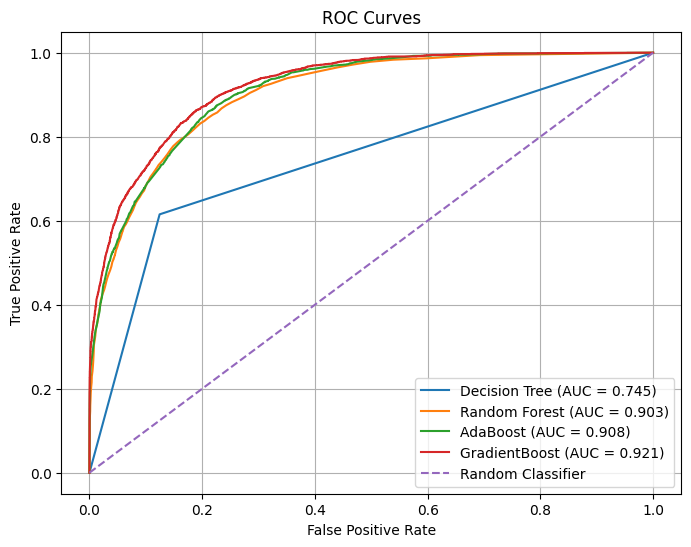

In [21]:
# plot ROC curves
plot_roc_curves(
    models=[dt_entropy, rf_100, adaboost_100, gradientboost_100],
    model_names=["Decision Tree", "Random Forest", "AdaBoost", "GradientBoost"],
    X_test=X_test,
    y_test=y_test,
    pos_label=">50K"
)

# Problem 4 [Naive Bayes Classifier]

in this problem you will implement your own naive bayes classifier and compare it with a package implementation. you will use the mushroom dataset. split the dataset into 75% for training and 25% for testing.

a. train the naive bayes classifier. compute the prior probabilities for the edible and poisonous classes from the training data. for each feature Xi in the dataset, compute the probabilities P[X=x|Y=edible] and P[X=x|Y=poisonous] from the training data. use the laplace smoothing method when computing these probabilities. the naive bayes classifier stores these prior and conditional probabilities.

In [22]:
mushroom_colnames = [
    "class", "cap_shape", "cap_surface", "cap_color", "bruises",
    "odor", "gill_attachment", "gill_spacing", "gill_size", "gill_color",
    "stalk_shape", "stalk_root", "stalk_surface_above_ring",
    "stalk_surface_below_ring", "stalk_color_above_ring", "stalk_color_below_ring",
    "veil_type", "veil_color", "ring_number", "ring_type",
    "spore_print_color", "population", "habitat"
]

# read in data
mushroom = pd.read_csv("mushroom/agaricus-lepiota.data",
                       header=None, names = mushroom_colnames)

# replace ?s with unknown
mushroom = mushroom.replace("?", "Unknown")

# separate class and features
X = mushroom.drop(columns=["class"])
y = mushroom["class"]

# 75/25 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [23]:
# naive bayes function

def train_naive_bayes(X_train, y_train):
    model = {}

    # class labels
    classes = y_train.unique()

    # prior probabilities
    priors = y_train.value_counts(normalize=True).to_dict()
    model["priors"] = priors

    # conditional probabilities
    conditionals = {}

    for feature in X_train.columns:
        conditionals[feature] = {}

        # all possible values of this feature
        feature_values = X_train[feature].unique()
        num_feature_values = len(feature_values)

        for clas in classes:
            conditionals[feature][clas] = {}

            # subset of training data for this class
            X_class = X_train[y_train == clas]

            # total number of rows in this class
            class_count = len(X_class)

            # counts of each feature value within this class
            value_counts = X_class[feature].value_counts()

            for value in feature_values:
                count = value_counts.get(value, 0)

                # laplace smoothing
                prob = (count + 1) / (class_count + num_feature_values)
                conditionals[feature][clas][value] = prob

    model["conditionals"] = conditionals

    return model

In [24]:
# train model using function
naivebayes = train_naive_bayes(X_train, y_train)

In [25]:
# prior probabilities for the edible and poisonous classes
naivebayes["priors"]

{'e': 0.5199409158050221, 'p': 0.48005908419497784}

In [26]:
# example of probabilities P[X=x|Y=edible] and P[X=x|Y=poisonous] for one feature (cap_shape)
naivebayes["conditionals"]["cap_shape"]

{'p': {'x': np.float64(0.43705220061412486),
  'f': np.float64(0.3889457523029683),
  'k': np.float64(0.1586489252814739),
  'b': np.float64(0.013647219379051518),
  's': 0.000341180484476288,
  'c': np.float64(0.001364721937905152)},
 'e': {'x': np.float64(0.4678638941398866),
  'f': np.float64(0.37744171392564585),
  'k': np.float64(0.057655954631379965),
  'b': np.float64(0.0888468809073724),
  's': np.float64(0.007876496534341524),
  'c': 0.000315059861373661}}

b. for each point in the testing set, estimate the probability that it belongs to the edible and poisonous classes. use the naive bayes classifier probabilities computed in part a.

In [27]:
# function to predict probabilities
def predict_naive_bayes_proba(model, X):
    classes = list(model["priors"].keys())
    results = []

    for _, row in X.iterrows():
        class_scores = {}

        for clas in classes:
            # start with log prior
            log_prob = np.log(model["priors"][clas])

            # add log conditional probabilities for each feature value
            for feature in X.columns:
                value = row[feature]
                prob = model["conditionals"][feature][clas][value]
                log_prob += np.log(prob)

            class_scores[clas] = log_prob

        # convert log scores back to regular probabilities
        max_log = max(class_scores.values())
        exp_scores = {clas: np.exp(score - max_log) for clas, score in class_scores.items()}
        total = sum(exp_scores.values())
        probs = {clas: exp_scores[clas] / total for clas in classes}

        results.append(probs)

    return pd.DataFrame(results, index=X.index)

In [28]:
nb_test_probs = predict_naive_bayes_proba(naivebayes, X_test)

nb_test_probs.head().round(7)

,e,p
1971,0.999993,0.000007
6654,0.000000,1.000000
5606,0.000000,1.000000
3332,1.000000,0.000000
6988,0.000000,1.000000


c. compute accuracy, precision, recall, and F1 score for your naive bayes classifier on the testing data.

In [29]:
# convert probabilities to predicted labels
y_test_pred_nb = nb_test_probs.idxmax(axis=1)

# generate probabilities (using poisonous as positive class)
y_test_prob_nb = nb_test_probs["p"]

# metrics for testing data
nb_test_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        accuracy_score(y_test, y_test_pred_nb),
        precision_score(y_test, y_test_pred_nb, pos_label="p"),
        recall_score(y_test, y_test_pred_nb, pos_label="p"),
        f1_score(y_test, y_test_pred_nb, pos_label="p")
    ]
})

nb_test_metrics.round(5)

,Metric,Value
0,Accuracy,0.94879
1,Precision,0.99006
2,Recall,0.90414
3,F1 Score,0.94515


d. compare the results obtained by your implementation with those obtained with a naive bayes package (trained on the same dataset). use several metrics, including accuracy, precision, recall, and F1 score. are the results similar or different? discuss your observations.

In [30]:
# encode categorical features as integer
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

# train naive bayes using package
package_nb = CategoricalNB(alpha=1.0)
package_nb.fit(X_train_enc, y_train)

# package predictions
y_test_pred_pkg = package_nb.predict(X_test_enc)

# package metrics
package_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Package NB": [
        accuracy_score(y_test, y_test_pred_pkg),
        precision_score(y_test, y_test_pred_pkg, pos_label="p"),
        recall_score(y_test, y_test_pred_pkg, pos_label="p"),
        f1_score(y_test, y_test_pred_pkg, pos_label="p")
    ]
})

package_metrics.round(5)

,Metric,Package NB
0,Accuracy,0.94879
1,Precision,0.99006
2,Recall,0.90414
3,F1 Score,0.94515
